<a href="https://colab.research.google.com/github/adhikaryramen87/MachineLearning_Works/blob/main/Image_Data_Quality_%26_Augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Resizing, Flipping & Rotation

Import all the required libraries

In [ ]:
import cv2
import matplotlib.pyplot as plt

Load the image and convert it to RGB

In [ ]:
# Load image
img = cv2.imread('/content/sample_image.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [ ]:
img.shape

(427, 640, 3)

Resize to 32 * 32 [CIFAR-10 Standard]

In [ ]:
target_size = (32, 32)
img_resized = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)

In [ ]:
img_resized.shape

(32, 32, 3)

Horizontal Flip (Mirroring)

In [ ]:
# 1 => horizontal, 0 => vertical, -1 => both
img_flipped = cv2.flip(img_resized, 1)

Rotation (45 degree)

In [ ]:
height, width = img_resized.shape[:2]
center = (width//2, height//2) # center of the image
# create the rotation matrix
matrix = cv2.getRotationMatrix2D(center, 40, 1.0)
# warpAffine -> is useful to do transformations in the given image
img_rotated = cv2.warpAffine(img_resized, matrix, (width, height))

Visualizations

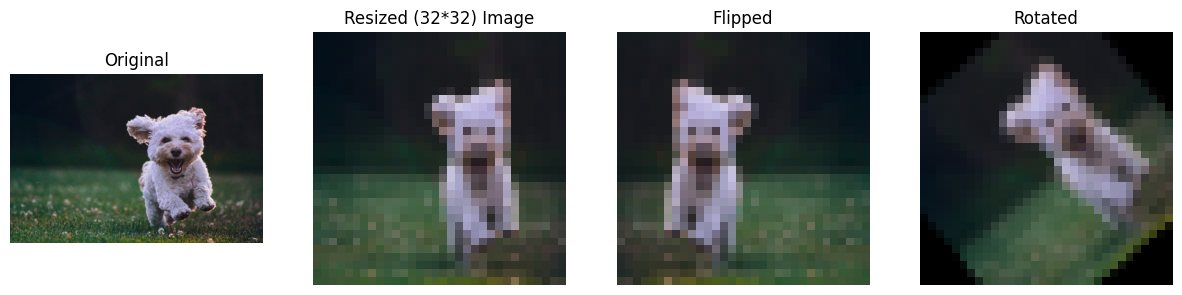

In [ ]:
titles = ['Original', 'Resized (32*32) Image', 'Flipped', 'Rotated']
images = [img, img_resized, img_flipped, img_rotated]

plt.figure(figsize=(15, 5))
for i in range(4):
  plt.subplot(1, 4, i+1)
  plt.imshow(images[i])
  plt.title(titles[i])
  plt.axis('off')
plt.show()

Overlaying Annotations

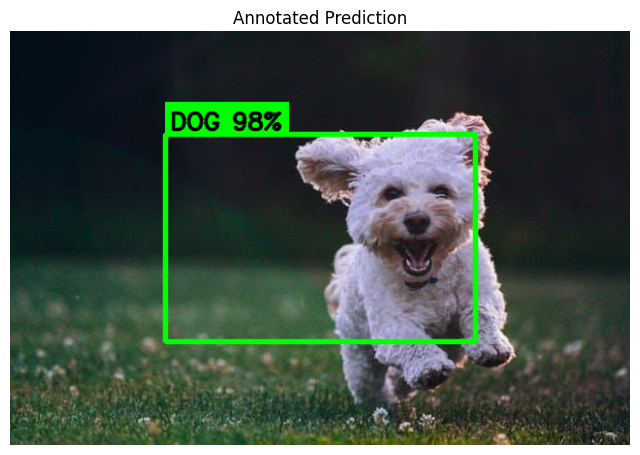

In [ ]:
# Copy original image (IMPORTANT)
img_annotated = img.copy()

# Image dimensions
h, w, _ = img.shape

# Bounding box coordinates
start_point = (int(w * 0.25), int(h * 0.25))
end_point   = (int(w * 0.75), int(h * 0.75))

# Draw bounding box
cv2.rectangle(
    img_annotated,
    start_point,
    end_point,
    color=(0, 255, 0), # green color
    thickness=3,
    lineType=cv2.LINE_AA
)

# --- TEXT BANNER (Filled Rectangle) ---
# manual labelling
label = "DOG 98%"
(text_width, text_height), _ = cv2.getTextSize(
    label,
    cv2.FONT_HERSHEY_SIMPLEX,
    0.8,
    2
)


banner_start = (start_point[0], start_point[1] - text_height - 15)
banner_end   = (start_point[0] + text_width + 10, start_point[1])

# Filled rectangle for text background
cv2.rectangle(
    img_annotated,
    banner_start,
    banner_end,
    color=(0, 255, 0),
    thickness=-1   # FILLED
)

# Put text on banner
cv2.putText(
    img_annotated,
    label,
    (start_point[0] + 5, start_point[1] - 5),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.8,
    (0, 0, 0), # black
    2,
    cv2.LINE_AA
)

# Display
plt.figure(figsize=(8, 6))
plt.imshow(img_annotated)
plt.title("Annotated Prediction")
plt.axis('off')
plt.show()

Stratify

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# 1. Imagine we have 100 images and 100 labels
# (In reality, these would be your CIFAR-10 images)
X = np.zeros((100, 32, 32, 3))
y = np.array([0]*50 + [1]*50) # 50 'Airplanes' (0), 50 'Birds' (1)

# 2. Perform a Stratified Split
# test_size=0.2 means 20% goes to testing
# stratify=y tells the code to keep the 50/50 ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 3. Verify the Hygiene
print(f"Training labels count: {np.bincount(y_train)}")
print(f"Testing labels count: {np.bincount(y_test)}")

Training labels count: [40 40]
Testing labels count: [10 10]


Data Imbalance Issue and Handling of that using class_weight computation

In [ ]:
import numpy as np
from sklearn.utils import class_weight

# Simulated labels for 1000 images: 900 'Healthy' (0), 100 'Disease' (1)
y_train = np.array([0]*900 + [1]*100)

# Calculate weights automatically
# This formula gives higher numbers to the smaller classes to level the playing field
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Convert to a dictionary for the frameworks
# Expected Result: {0: 0.55, 1: 5.0}
# Note: The '1' class (Truck) is now roughly 9x more "important" during training
weight_dict = dict(enumerate(weights))

print(f"Class 0 [Healthy] weight: {weight_dict[0]:.2f}")
print(f"Class 1 [Disease] weight: {weight_dict[1]:.2f}")

Class 0 [Healthy] weight: 0.56
Class 1 [Disease] weight: 5.00


Error Analysis

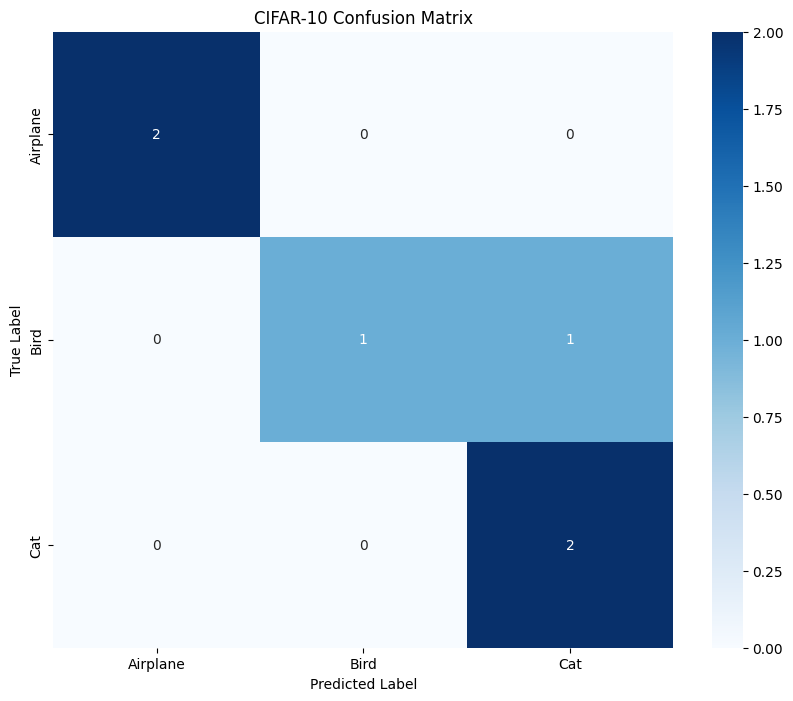

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Get the model's predictions on the test set
# (Assuming 'y_test' are true labels and 'y_pred' are model guesses)
y_true = [0, 1, 2, 2, 0, 1] # Real: Airplane, Bird, Cat...
y_pred = [0, 2, 2, 2, 0, 1] # Model: Missed one Bird, thought it was a Cat
class_names = ['Airplane', 'Bird', 'Cat']

# 2. Create the matrix
cm = confusion_matrix(y_true, y_pred)

# 3. Plot as a Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('CIFAR-10 Confusion Matrix')
plt.show()

Data Augmentation

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

data_augmentation = models.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

# Integerate into our main model
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    data_augmentation,
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(10, activation='softmax')
])

End-To-End CNN Pipeline for CIFAR-10 data

In [ ]:
from tensorflow import keras
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
print(y_train)

[[6]
 [9]
 [9]
 ...
 [9]
 [1]
 [1]]


In [ ]:
print(y_test)

[[3]
 [8]
 [8]
 ...
 [5]
 [1]
 [7]]


In [ ]:
X_train.shape

(50000, 32, 32, 3)

In [ ]:
X_test.shape

(10000, 32, 32, 3)

Normalize Data

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

Train-Validation Set (Stratified Mindset)

Data Augmentation

Build CNN

Compile the Model

Callbacks

Train Model

Evaluate Model

Predictions + Analysis

Test_Set => Resized to the standard size of CIFAR-10 dataset (32,32,3)

Overlay Annotations

Once done, please share your work at techforallwithpriya@gmail.com